# Прогнозирование времени в пути в дорожном графе с помощью GNN (METR-LA + PyTorch Geometric Temporal)


## Датасет

**METR-LA**: 207 сенсоров (узлы графа), измерения скорости каждые 5 минут (март–июнь 2012).  
Датасет поддерживается в `pytorch-geometric-temporal`.

Источники:
- Документация PyTorch Geometric Temporal по загрузчикам METR-LA.
- ZIP-архив METR-LA с `graphmining.ai`.


---

# 0. Настройка окружения

Дальше будут:
1) установка библиотек,  
2) фиксирование seed,  
3) автоматическое скачивание датасета.



In [1]:
!pip -q uninstall -y torch torchvision torchaudio
!pip -q uninstall -y torch-geometric torch-geometric-temporal pyg-lib \
  torch-scatter torch-sparse torch-cluster torch-spline-conv triton torchtriton

!pip -q install --upgrade pip

!pip -q install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
  --index-url https://download.pytorch.org/whl/cu121

!pip -q install torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-2.3.1+cu121.html

!pip -q install torch-geometric torch-geometric-temporal


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.5 requires torch<2.10,>=1.10, which is not installed.
fastai 2.8.5 requires torchvision>=0.11, which is not installed.


In [1]:
# Runtime -> Restart runtime
import torch
print("torch:", torch.__version__, "cuda:", torch.version.cuda)

from torch_geometric_temporal.dataset import METRLADatasetLoader
from torch_geometric_temporal.nn.recurrent import TGCN

print("OK")

torch: 2.3.1+cu121 cuda: 12.1
OK


In [2]:
# Импорты
import os, random, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn


In [3]:
# Фиксируем seed для воспроизводимости
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

---

# 1. Автоматическая загрузка датасета METR-LA

`METRLADatasetLoader` при необходимости скачивает и подготавливает датасет.

Мы решаем задачу **прогноза скорости на следующий шаг** (5 минут вперёд) по окну истории `T_in`.


In [4]:
from torch_geometric_temporal.dataset import METRLADatasetLoader

loader = METRLADatasetLoader()
dataset = loader.get_dataset(num_timesteps_in=12, num_timesteps_out=1)

dataset


13.6MB [00:00, 54.5MB/s]


---

# 2. Проверка формата данных


In [5]:
snapshot = next(iter(dataset))
snapshot


Data(x=[207, 2, 12], edge_index=[2, 1722], edge_attr=[1722], y=[207, 1])

In [6]:
x = snapshot.x
y = snapshot.y
edge_index = snapshot.edge_index
edge_attr = snapshot.edge_attr

print("x shape:", tuple(x.shape))  # [num_nodes, num_timesteps_in]
print("y shape:", tuple(y.shape))  # [num_nodes, num_timesteps_out]
print("num_nodes:", x.shape[0])
print("num_edges:", edge_index.shape[1])
print("edge_attr shape:", tuple(edge_attr.shape))


x shape: (207, 2, 12)
y shape: (207, 1)
num_nodes: 207
num_edges: 1722
edge_attr shape: (1722,)


---

# 3. EDA


In [7]:
# Сэмпл по времени для EDA (чтобы не держать всё в памяти)
N = 2000
xs, ys = [], []
for i, snap in enumerate(dataset):
    xs.append(snap.x.cpu().numpy())
    ys.append(snap.y.cpu().numpy())
    if i + 1 >= N:
        break

X_sample = np.stack(xs, axis=0)  # [N, num_nodes, T_in]
Y_sample = np.stack(ys, axis=0)  # [N, num_nodes, 1]
X_sample.shape, Y_sample.shape


((2000, 207, 2, 12), (2000, 207, 1))

min: -2.6521542072296143 max: 1.729145884513855 mean: 0.0659291073679924 std: 0.928698718547821


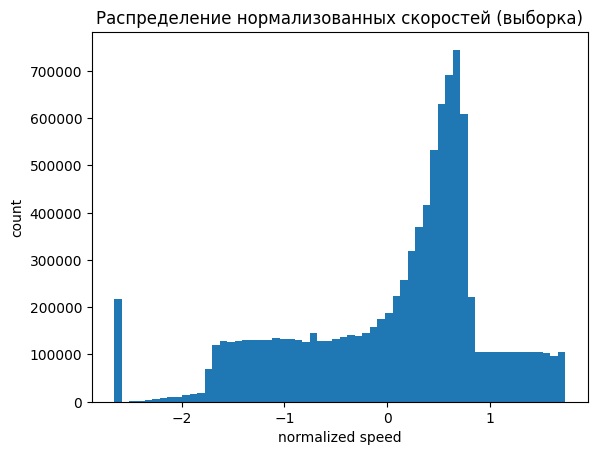

In [8]:
vals = X_sample.reshape(-1)
vals = vals[np.isfinite(vals)]

print("min:", float(vals.min()), "max:", float(vals.max()), "mean:", float(vals.mean()), "std:", float(vals.std()))

plt.figure()
plt.hist(vals, bins=60)
plt.title("Распределение нормализованных скоростей (выборка)")
plt.xlabel("normalized speed")
plt.ylabel("count")
plt.show()


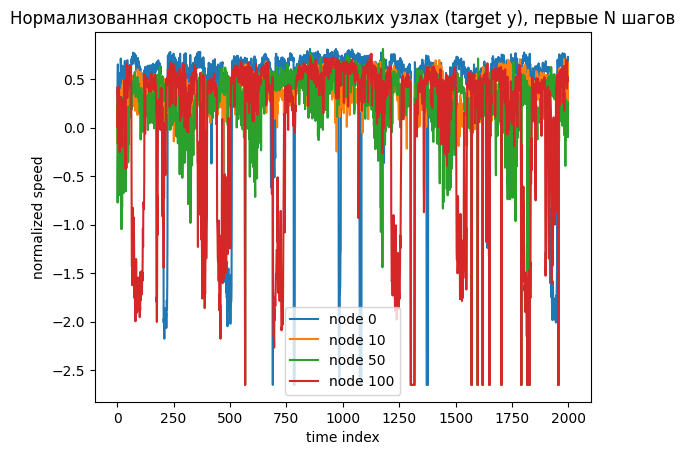

In [9]:
nodes_to_plot = [0, 10, 50, 100]
t = np.arange(N)

plt.figure()
for n in nodes_to_plot:
    plt.plot(t, Y_sample[:, n, 0], label=f"node {n}")
plt.title("Нормализованная скорость на нескольких узлах (target y), первые N шагов")
plt.xlabel("time index")
plt.ylabel("normalized speed")
plt.legend()
plt.show()


---

# 4. Метрики и временное разделение


In [10]:
def mae(pred, true):
    return torch.mean(torch.abs(pred - true))

def rmse(pred, true):
    return torch.sqrt(torch.mean((pred - true) ** 2))

def mape(pred, true, eps=1e-3):
    denom = torch.clamp(torch.abs(true), min=eps)
    return torch.mean(torch.abs((pred - true) / denom)) * 100.0


In [11]:
T = dataset.snapshot_count
print(T)
train_end = int(T * 0.7)
val_end   = int(T * 0.8)

train_indices = list(range(0, train_end))
val_indices   = list(range(train_end, val_end))
test_indices  = list(range(val_end, T))

len(train_indices), len(val_indices), len(test_indices), T


34260


(23982, 3426, 6852, 34260)

---

# 5. Baseline 1: Persistence (последнее значение)


In [14]:
@torch.no_grad()
def evaluate_persistence(dataset_slice):
    maes, rmses, mapes = [], [], []
    for snapshot in dataset_slice:
        # snapshot.x: [N, F, T]  (у тебя F=2, T=12)
        # snapshot.y: [N, 1]

        # берём 0-й признак (скорость) и последний момент времени
        pred = snapshot.x[:, 0, -1]              # [N]
        true = snapshot.y.squeeze(-1)            # [N]

        maes.append(mae(pred, true).item())
        rmses.append(rmse(pred, true).item())
        mapes.append(mape(pred, true).item())

    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(mapes))


persist_test = evaluate_persistence(dataset)
persist_test


(0.14383914767064793, 0.2376855942945312, 86.10201094271632)

---

# 6. Baseline 2: MLP без графа


In [15]:
from torch.utils.data import Dataset, DataLoader

class NodeWindowDataset(Dataset):
    def __init__(self, pyg_temporal_dataset, indices):
        self.ds = pyg_temporal_dataset
        self.indices = indices
        self.num_nodes = self.ds[0].x.shape[0]
    def __len__(self):
        return len(self.indices) * self.num_nodes
    def __getitem__(self, idx):
        t_idx = idx // self.num_nodes
        n_idx = idx % self.num_nodes
        snap = self.ds[self.indices[t_idx]]
        x = snap.x[n_idx, 0, :]   # [T_in] — берём 0-й признак (скорость)
        y = snap.y[n_idx]         # [1]
        return x.float(), y.float()

train_node_ds = NodeWindowDataset(dataset, train_indices)
val_node_ds   = NodeWindowDataset(dataset, val_indices)
test_node_ds  = NodeWindowDataset(dataset, test_indices)

train_loader = DataLoader(train_node_ds, batch_size=1024, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_node_ds, batch_size=2048, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_node_ds, batch_size=2048, shuffle=False, num_workers=0)

len(train_node_ds), len(test_node_ds)


(4964274, 1418364)

In [16]:
class MLPBaseline(nn.Module):
    def __init__(self, T_in: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(T_in, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x)

mlp = MLPBaseline(T_in=12, hidden=64).to(device)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.L1Loss()

def eval_mlp(model, loader):
    model.eval()
    maes, rmses, mapes = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            maes.append(mae(pred, yb).item())
            rmses.append(rmse(pred, yb).item())
            mapes.append(mape(pred, yb).item())
    return float(np.mean(maes)), float(np.mean(rmses)), float(np.mean(mapes))

for epoch in range(1, 11):
    mlp.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        pred = mlp(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    val_metrics = eval_mlp(mlp, val_loader)
    print(f"epoch={epoch:02d} train_L1={total_loss/len(train_loader):.4f} | "
          f"val_MAE={val_metrics[0]:.4f} val_RMSE={val_metrics[1]:.4f} val_MAPE={val_metrics[2]:.2f}%")

mlp_test = eval_mlp(mlp, test_loader)
mlp_test


epoch=01 train_L1=0.1330 | val_MAE=0.1258 val_RMSE=0.2472 val_MAPE=73.43%
epoch=02 train_L1=0.1286 | val_MAE=0.1238 val_RMSE=0.2451 val_MAPE=73.21%
epoch=03 train_L1=0.1279 | val_MAE=0.1233 val_RMSE=0.2448 val_MAPE=73.03%
epoch=04 train_L1=0.1274 | val_MAE=0.1246 val_RMSE=0.2458 val_MAPE=73.18%
epoch=05 train_L1=0.1272 | val_MAE=0.1229 val_RMSE=0.2444 val_MAPE=73.17%
epoch=06 train_L1=0.1269 | val_MAE=0.1223 val_RMSE=0.2441 val_MAPE=72.75%
epoch=07 train_L1=0.1266 | val_MAE=0.1220 val_RMSE=0.2444 val_MAPE=73.76%
epoch=08 train_L1=0.1264 | val_MAE=0.1221 val_RMSE=0.2450 val_MAPE=74.60%
epoch=09 train_L1=0.1264 | val_MAE=0.1227 val_RMSE=0.2449 val_MAPE=73.55%
epoch=10 train_L1=0.1262 | val_MAE=0.1224 val_RMSE=0.2454 val_MAPE=73.93%


(0.12923219581746093, 0.25958209421249134, 78.18618662885429)

---

# 7. GCN - SAGEConv


In [12]:
import numpy as np
import torch
from torch import nn
from torch_geometric.nn import SAGEConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def mae(pred, true):  return torch.mean(torch.abs(pred - true))
def rmse(pred, true): return torch.sqrt(torch.mean((pred - true) ** 2))

class WindowSAGE(nn.Module):
    """Простой GraphSAGE по одному окну (T_in=12) на узел.

    x: [N, T_in] (мы берём 0‑й признак из snapshot.x: скорость)
    edge_index: [2, E]
    """
    def __init__(self, in_channels=12, hidden=256, dropout=0.2):
        super().__init__()
        self.mlp_in = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
        )
        self.conv1 = SAGEConv(hidden, hidden)
        self.conv2 = SAGEConv(hidden, hidden)

        # Нормализация помогает стабилизировать обучение на METR‑LA
        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)

        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, edge_index):
        h0 = self.mlp_in(x)                          # [N, hidden]
        h1 = torch.relu(self.conv1(h0, edge_index))  # [N, hidden]
        h1 = self.norm1(h1)
        h = h0 + h1                                  # residual: можно игнорировать соседей

        h2 = torch.relu(self.conv2(h, edge_index))
        h2 = self.norm2(h2)
        h = h + h2                                   # residual №2
        return self.head(h).squeeze(-1)              # [N]

# ============================================================
# 2) Temporal + GraphSAGE: маленькая 1D‑CNN по времени на узел,
#    затем SAGEConv по графу.
# ============================================================

class TemporalSAGE(nn.Module):
    """1D‑CNN по времени + 2 слоя SAGEConv по графу."""
    def __init__(self, T_in=12, hidden=128, dropout=0.2):
        super().__init__()
        # Вход: [N, T_in] -> добавляем канал и гоним через Conv1d: [N, 1, T_in]
        self.temporal = nn.Sequential(
            nn.Conv1d(1, hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # [N, hidden, 1]
        )

        self.conv1 = SAGEConv(hidden, hidden)
        self.conv2 = SAGEConv(hidden, hidden)

        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)

        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, edge_index):
        # x: [N, T_in]
        h0 = self.temporal(x.unsqueeze(1)).squeeze(-1)  # [N, hidden]
        h1 = torch.relu(self.conv1(h0, edge_index))
        h1 = self.norm1(h1)
        h = h0 + h1

        h2 = torch.relu(self.conv2(h, edge_index))
        h2 = self.norm2(h2)
        h = h + h2
        return self.head(h).squeeze(-1)

# ============================================================

def train_gnn(model, train_indices, val_indices, *, epochs=60, patience=8, lr=2e-3, weight_decay=1e-5):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3, verbose=False)
    loss_fn = nn.L1Loss()

    best_val = float("inf")
    best_state = None
    bad = 0

    def run_epoch(indices, train=True):
        model.train() if train else model.eval()
        losses, maes, rmses = [], [], []
        for i in indices:
            s = dataset[i]
            # Важно: используем тот же признак (0‑й), что и в MLP baseline,
            # иначе сравнение будет нечестным.
            x = s.x[:, 0, :].to(device)          # [N, 12]
            y = s.y.to(device).view(-1)          # [N]
            edge_index = s.edge_index.to(device)

            if train:
                opt.zero_grad(set_to_none=True)

            with torch.set_grad_enabled(train):
                pred = model(x, edge_index)
                loss = loss_fn(pred, y)

                if train:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()

            losses.append(loss.item())
            maes.append(mae(pred, y).item())
            rmses.append(rmse(pred, y).item())
        return float(np.mean(losses)), float(np.mean(maes)), float(np.mean(rmses))

    for epoch in range(1, epochs + 1):
        tr = run_epoch(train_indices, train=True)
        va = run_epoch(val_indices, train=False)
        sched.step(va[1])

        print(f"epoch={epoch:02d} | train_MAE={tr[1]:.4f} RMSE={tr[2]:.4f} || val_MAE={va[1]:.4f} RMSE={va[2]:.4f}")

        # early stopping по val MAE
        if va[1] + 1e-6 < best_val:
            best_val = va[1]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping: no val improvement for {patience} epochs.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def eval_gnn(model, test_indices):
    model.eval()
    maes, rmses = [], []
    with torch.no_grad():
        for i in test_indices:
            s = dataset[i]
            x = s.x[:, 0, :].to(device)
            y = s.y.to(device).view(-1)
            edge_index = s.edge_index.to(device)
            pred = model(x, edge_index)
            maes.append(mae(pred, y).item())
            rmses.append(rmse(pred, y).item())
    return float(np.mean(maes)), float(np.mean(rmses))

# ------------------------------------------------------------
# Запуск: TemporalSAGE
# ------------------------------------------------------------
sage_model = TemporalSAGE(T_in=12, hidden=128, dropout=0.25)
sage_model = train_gnn(sage_model, train_indices, val_indices, epochs=60, patience=8, lr=2e-3)

sage_test = eval_gnn(sage_model, test_indices)
print("TemporalSAGE test:", sage_test)

try:
    print("MLP test (MAE, RMSE, MAPE):", mlp_test)
except NameError:
    pass


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


epoch=01 | train_MAE=0.1561 RMSE=0.2528 || val_MAE=0.1360 RMSE=0.2207
epoch=02 | train_MAE=0.1509 RMSE=0.2468 || val_MAE=0.1341 RMSE=0.2194
epoch=03 | train_MAE=0.1494 RMSE=0.2449 || val_MAE=0.1341 RMSE=0.2227
epoch=04 | train_MAE=0.1483 RMSE=0.2436 || val_MAE=0.1261 RMSE=0.2158
epoch=05 | train_MAE=0.1477 RMSE=0.2429 || val_MAE=0.1303 RMSE=0.2189
epoch=06 | train_MAE=0.1475 RMSE=0.2426 || val_MAE=0.1272 RMSE=0.2164
epoch=07 | train_MAE=0.1469 RMSE=0.2418 || val_MAE=0.1259 RMSE=0.2156
epoch=08 | train_MAE=0.1467 RMSE=0.2416 || val_MAE=0.1260 RMSE=0.2157
epoch=09 | train_MAE=0.1466 RMSE=0.2415 || val_MAE=0.1252 RMSE=0.2146
epoch=10 | train_MAE=0.1464 RMSE=0.2413 || val_MAE=0.1290 RMSE=0.2185
epoch=11 | train_MAE=0.1464 RMSE=0.2412 || val_MAE=0.1270 RMSE=0.2168
epoch=12 | train_MAE=0.1463 RMSE=0.2411 || val_MAE=0.1343 RMSE=0.2231
epoch=13 | train_MAE=0.1461 RMSE=0.2409 || val_MAE=0.1252 RMSE=0.2143
epoch=14 | train_MAE=0.1452 RMSE=0.2398 || val_MAE=0.1335 RMSE=0.2230
epoch=15 | train_MAE

# Sanity-check предиктор на sarimax для сравнения

In [19]:
# ============================================================
# Time-Series baseline по каждому узлу: SARIMAX
# ============================================================
# 1) оцениваем не на всех узлах, а на подмножестве (n_nodes_eval)
# 2) берём только "хвост" train-серии (train_tail)
# 3) прогнозируем только первые test_horizon точек теста
# 4) оставляем rolling 1-step с append, но по короткому горизонту
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX

def extract_node_series(pyg_temporal_dataset, node_id: int):
    """Достаём полный ряд скорости (0-й признак) для node_id по всем snapshot'ам."""
    vals = []
    for t in range(pyg_temporal_dataset.snapshot_count):
        s = pyg_temporal_dataset[t]
        vals.append(float(s.x[node_id, 0, -1]))
    return np.array(vals, dtype=np.float32)

def fit_sarimax(train_series, order=(1,0,1), seasonal_order=(0,0,0,0), maxiter=20):
    """Фитим SARIMAX на train. Возвращаем fitted results или None."""
    try:
        model = SARIMAX(
            train_series,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        res = model.fit(disp=False, maxiter=maxiter)
        return res
    except Exception:
        return None

def eval_sarimax_subset_nodes(
    dataset,
    train_indices,
    test_indices,
    order=(1,0,1),
    seasonal_order=(0,0,0,0),
    maxiter=20,
    n_nodes_eval=30,
    train_tail=250,
    test_horizon=80,
    seed=42,
):
    """
    Быстрый sanity-check SARIMAX:
    - считаем метрики только на n_nodes_eval узлах
    - учим на последних train_tail точках train
    - прогнозируем только test_horizon точек test
    """
    num_nodes = dataset[0].x.shape[0]

    rng = np.random.default_rng(seed)
    if n_nodes_eval >= num_nodes:
        nodes = np.arange(num_nodes)
    else:
        nodes = rng.choice(num_nodes, size=n_nodes_eval, replace=False)

    maes, rmses = [], []

    for node in nodes:
        full = extract_node_series(dataset, node)
        y_full = full[1:]  # target-ряд, согласованный с y(t)=speed_{t+1}

        train_idx = [i for i in train_indices if i < len(y_full)]
        test_idx  = [i for i in test_indices  if i < len(y_full)]

        y_train = y_full[train_idx]
        y_test  = y_full[test_idx]

        # Укорачиваем train и test для скорости
        if len(y_train) > train_tail:
            y_train = y_train[-train_tail:]
        if len(y_test) > test_horizon:
            y_test = y_test[:test_horizon]

        if len(y_train) < 30 or len(y_test) < 5:
            continue

        res = fit_sarimax(y_train, order=order, seasonal_order=seasonal_order, maxiter=maxiter)

        if res is None:
            # fallback: наивный прогноз
            pred = np.r_[y_train[-1], y_test[:-1]]
        else:
            # Rolling 1-step прогноз, но только на коротком горизонте
            pred = []
            cur_res = res
            ok = True
            for true_val in y_test:
                try:
                    fc = cur_res.forecast(1)
                    pred.append(float(fc[0]))
                    cur_res = cur_res.append([true_val], refit=False)
                except Exception:
                    ok = False
                    break
            if not ok:
                pred = np.r_[y_train[-1], y_test[:-1]]
            pred = np.array(pred, dtype=np.float32)

        maes.append(np.mean(np.abs(pred - y_test)))
        rmses.append(np.sqrt(np.mean((pred - y_test) ** 2)))

    if len(maes) == 0:
        return float("nan"), float("nan"), int(0), nodes

    return float(np.mean(maes)), float(np.mean(rmses)), int(len(maes)), nodes

sarimax_mae, sarimax_rmse, used_nodes, nodes_eval = eval_sarimax_subset_nodes(
    dataset,
    train_indices=train_indices,
    test_indices=test_indices,
    order=(1,0,1),
    seasonal_order=(0,0,0,0),
    maxiter=15,
    n_nodes_eval=100,
    train_tail=250,
    test_horizon=80,
    seed=42,
)

print(f"SARIMAX per-node subset test (MAE, RMSE): {(sarimax_mae, sarimax_rmse)}")
print(f"Evaluated nodes: {used_nodes} / {len(nodes_eval)} (requested)")
print("Node ids:", nodes_eval[:10], "...")


SARIMAX per-node subset test (MAE, RMSE): (0.157117560505867, 0.2570120096206665)
Evaluated nodes: 100 / 100 (requested)
Node ids: [ 82 176 186  75 137 122  25  56  24  87] ...


---

# 8. Сравнение метрик на test


In [20]:
results = pd.DataFrame([
    {
        "model": "Persistence (last value)",
        "MAE": persist_test[0],
        "RMSE": persist_test[1],
    },
    {
        "model": "MLP (no graph)",
        "MAE": mlp_test[0],
        "RMSE": mlp_test[1],
    },
    {
        "model": "GraphSAGE (GNN)",
        "MAE": sage_test[0],
        "RMSE": sage_test[1],
    },
    {
        "model": f"SARIMAX (per-node, subset={used_nodes})",
        "MAE": sarimax_mae,
        "RMSE": sarimax_rmse,
    },
]).sort_values("MAE").reset_index(drop=True)

results


,model,MAE,RMSE
0,MLP (no graph),0.129232,0.259582
1,GraphSAGE (GNN),0.130038,0.222424
2,Persistence (last value),0.143839,0.237686
3,"SARIMAX (per-node, subset=100)",0.157118,0.257012


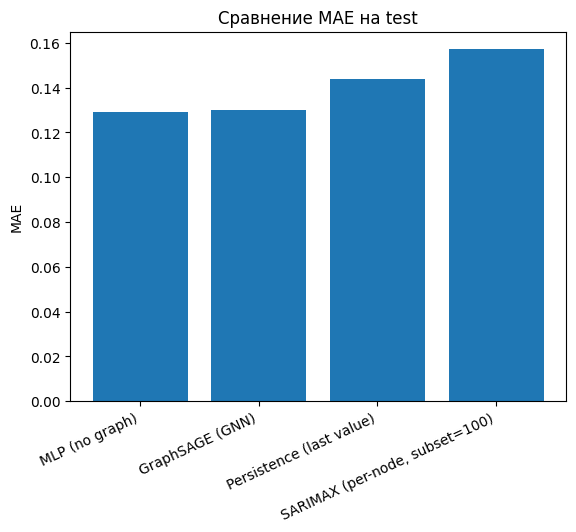

In [21]:
plt.figure()
plt.bar(results["model"], results["MAE"])
plt.title("Сравнение MAE на test")
plt.xticks(rotation=25, ha="right")
plt.ylabel("MAE")
plt.show()


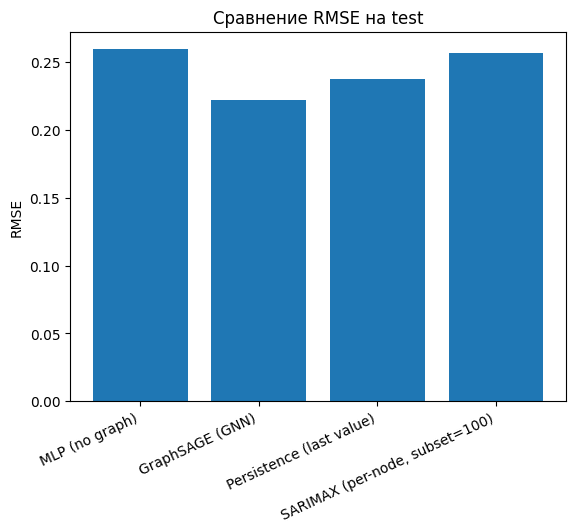

In [23]:
plt.figure()
plt.bar(results["model"], results["RMSE"])
plt.title("Сравнение RMSE на test")
plt.xticks(rotation=25, ha="right")
plt.ylabel("RMSE")
plt.show()


---

# 9. От скорости к времени в пути: демонстрация на маршруте

Оценим время в пути как сумму `dist / speed` по рёбрам пути.


In [24]:
import networkx as nx

snap0 = dataset[val_indices[0]]
edge_index_np = snap0.edge_index.cpu().numpy()
edge_attr_np = snap0.edge_attr.cpu().numpy().reshape(-1)

G = nx.Graph()
num_nodes = snap0.x.shape[0]
G.add_nodes_from(range(num_nodes))
for (u, v), w in zip(edge_index_np.T, edge_attr_np):
    G.add_edge(int(u), int(v), dist=float(w))

components = list(nx.connected_components(G))
largest = max(components, key=len)
nodes = list(largest)
src, dst = nodes[0], nodes[len(nodes)//2]
src, dst, len(largest)


(0, 104, 206)

In [36]:
# ============================================================
# Travel time по маршруту: true vs pred
# это "условное время" (скорости нормализованы), не секунды/минуты.
# ============================================================

import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F

def speed_to_positive(speed_vec, vmin=0.1):
    """
    Преобразуем нормализованные скорости (могут быть отрицательными)
    в положительные, монотонно (чтобы сравнение pred/true было корректным).
    softplus(x) ~ max(0, x), но гладко и всегда > 0.
    """
    s = torch.tensor(speed_vec, dtype=torch.float32)
    s_pos = F.softplus(s)  # всегда > 0
    s_pos = torch.clamp(s_pos, min=vmin)
    return s_pos.cpu().numpy()

def route_travel_time(path, speed_vec_norm, G, vmin=0.1):
    sp = speed_to_positive(speed_vec_norm, vmin=vmin)
    total = 0.0
    for a, b in zip(path[:-1], path[1:]):
        d = float(G[a][b]["dist"])
        v = 0.5 * (float(sp[a]) + float(sp[b]))
        total += d / v
    return total

# --- snapshot ---
i = int(test_indices[0])
snap = dataset[i]

# вход как в train/eval
x = snap.x[:, 0, :].to(device)
edge_index = snap.edge_index.to(device)

sage_model.eval()
with torch.no_grad():
    pred = sage_model(x, edge_index).view(-1).cpu().numpy()

true = snap.y.view(-1).cpu().numpy()

path = nx.shortest_path(G, src, dst, weight="dist")

t_true = route_travel_time(path, true, G, vmin=0.1)
t_pred = route_travel_time(path, pred, G, vmin=0.1)

print(" Время в пути в 'normalized-units' (softplus), вытаскивать реальные секунды надо отдельно.")
print("snapshot index:", i)
print("path length (nodes):", len(path))
print("travel time (true*):", t_true)
print("travel time (pred*):", t_pred)
print("abs error:", abs(t_pred - t_true))
print("rel error (%):", 100.0 * abs(t_pred - t_true) / max(1e-6, t_true))


 Время в пути в 'normalized-units' (softplus), вытаскивать реальные секунды надо отдельно.
snapshot index: 27408
path length (nodes): 9
travel time (true*): 1.183530658685466
travel time (pred*): 1.1577039771680064
abs error: 0.025826681517459482
rel error (%): 2.1821725806532872


---

# 10. Идеи дополнительных экспериментов

- горизонты прогноза (15/30/60 минут): `num_timesteps_out=3/6/12`
- разные окна истории: `T_in=6/12/24`
- другие модели: `TGCN`, `GConvGRU`, `GConvLSTM` (которые, увы, не отработали в колабе в рамках этого проекта)


---

# 11. Выводы

## Выводы
- Persistence даёт сильный baseline на коротком горизонте.
- MLP без графа уже работает хорошо и обходит persistance
- Spatio-temporal GNN и немного выигрывает по RMSE, но сопоставим по MAE c MLP
- SARIMAX предиктор даже хуже persistance
- НО -- это все на короткий диапазон планирования. Интересно проверять на несколько шагов вперед

